Import Python Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Data Analyses

In [3]:
df = pd.read_csv("Bengaluru_House_Data.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

df["bhk"] = df["size"].str.extract("(\d+)").astype(float)
df["total_sqft"] = pd.to_numeric(df["total_sqft"], errors="coerce")

Dataset Shape: (13320, 9)

Columns:
Index(['area_type', 'availability', 'location', 'size', 'society',
       'total_sqft', 'bath', 'balcony', 'price'],
      dtype='object')

First 5 rows:
              area_type   availability                  location       size  \
0  Super built-up  Area         19-Dec  Electronic City Phase II      2 BHK   
1            Plot  Area  Ready To Move          Chikka Tirupathi  4 Bedroom   
2        Built-up  Area  Ready To Move               Uttarahalli      3 BHK   
3  Super built-up  Area  Ready To Move        Lingadheeranahalli      3 BHK   
4  Super built-up  Area  Ready To Move                  Kothanur      2 BHK   

   society total_sqft  bath  balcony   price  
0  Coomee        1056   2.0      1.0   39.07  
1  Theanmp       2600   5.0      3.0  120.00  
2      NaN       1440   2.0      3.0   62.00  
3  Soiewre       1521   3.0      1.0   95.00  
4      NaN       1200   2.0      1.0   51.00  

Missing Values:
area_type          0
availability   

<>:13: SyntaxWarning: invalid escape sequence '\d'
<>:13: SyntaxWarning: invalid escape sequence '\d'
C:\Users\jdp18\AppData\Local\Temp\ipykernel_18108\874000620.py:13: SyntaxWarning: invalid escape sequence '\d'
  df["bhk"] = df["size"].str.extract("(\d+)").astype(float)


Data Visulation

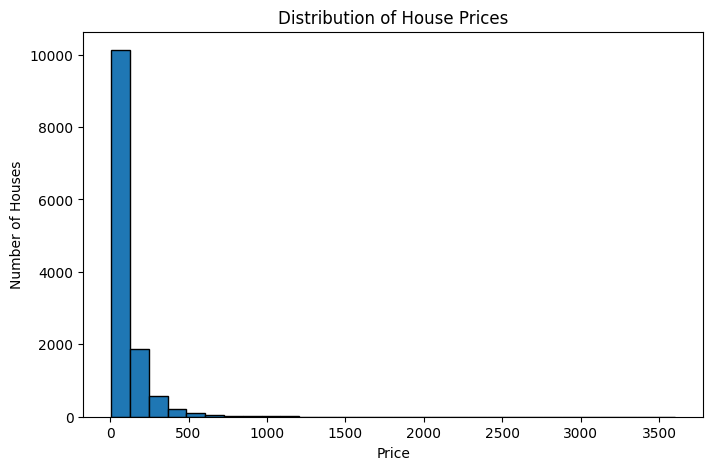

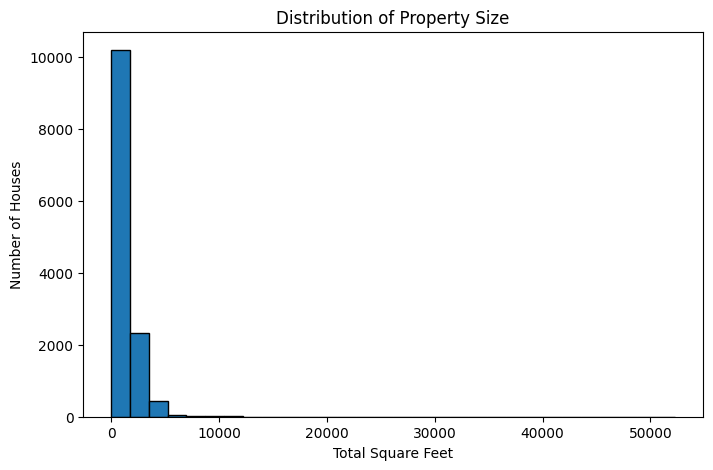

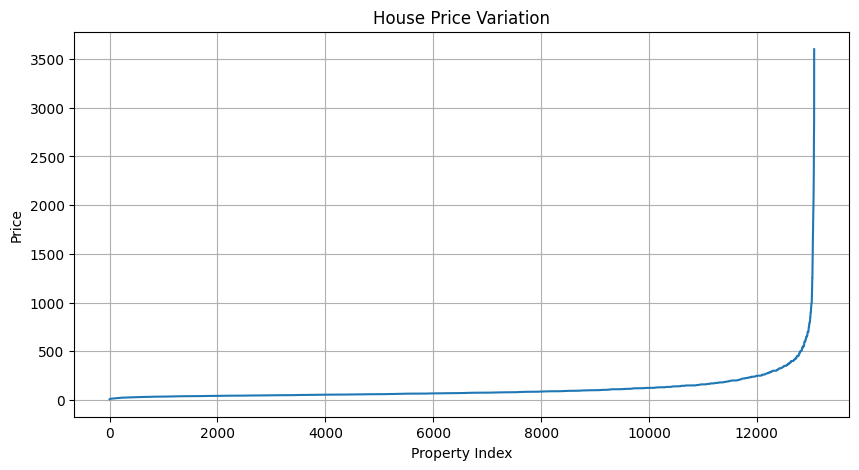

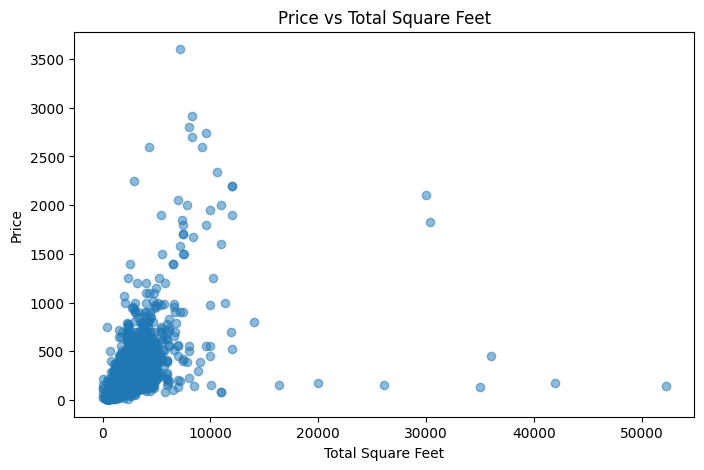

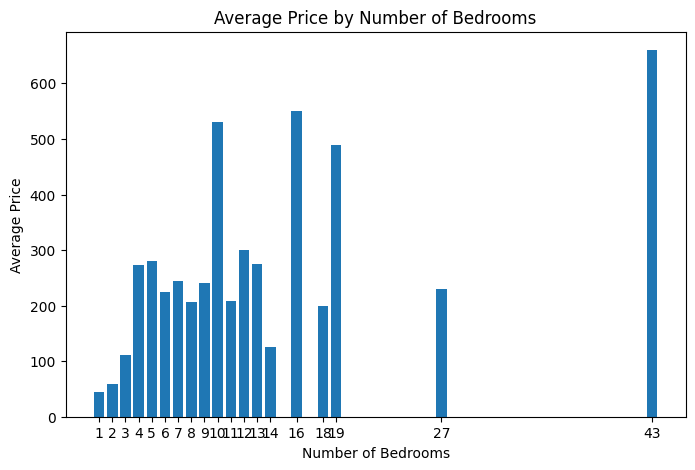

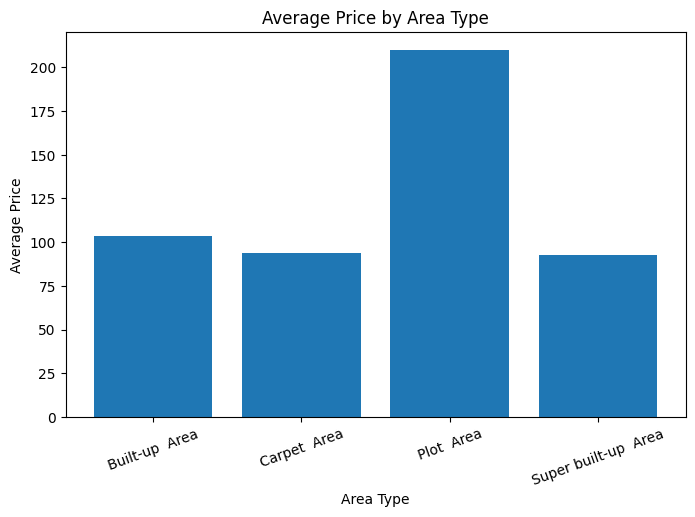

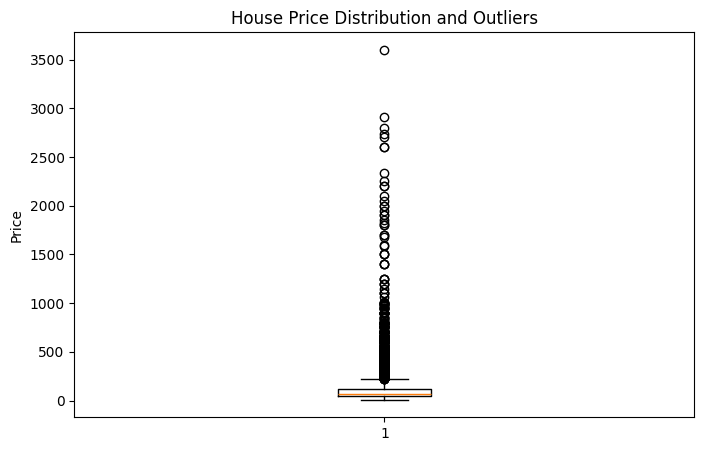

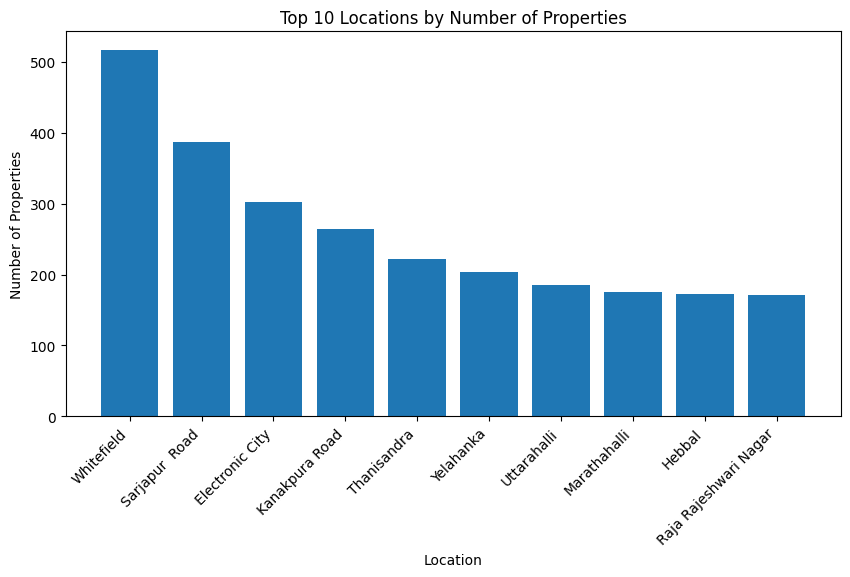

In [4]:
df = df.dropna(subset=["price", "total_sqft", "bhk"])

plt.figure(figsize=(8, 5))
plt.hist(df["price"], bins=30, edgecolor="black")
plt.xlabel("Price")
plt.ylabel("Number of Houses")
plt.title("Distribution of House Prices")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(df["total_sqft"], bins=30, edgecolor="black")
plt.xlabel("Total Square Feet")
plt.ylabel("Number of Houses")
plt.title("Distribution of Property Size")
plt.show()

price_data = df["price"].sort_values().reset_index(drop=True)

plt.figure(figsize=(10, 5))
plt.plot(price_data)
plt.xlabel("Property Index")
plt.ylabel("Price")
plt.title("House Price Variation")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(df["total_sqft"], df["price"], alpha=0.5)
plt.xlabel("Total Square Feet")
plt.ylabel("Price")
plt.title("Price vs Total Square Feet")
plt.show()

avg_price_bhk = df.groupby("bhk")["price"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_price_bhk.index, avg_price_bhk.values)
plt.xlabel("Number of Bedrooms")
plt.ylabel("Average Price")
plt.title("Average Price by Number of Bedrooms")
plt.xticks(avg_price_bhk.index)
plt.show()

avg_price_area = df.groupby("area_type")["price"].mean()

plt.figure(figsize=(8, 5))
plt.bar(avg_price_area.index, avg_price_area.values)
plt.xlabel("Area Type")
plt.ylabel("Average Price")
plt.title("Average Price by Area Type")
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(8, 5))
plt.boxplot(df["price"])
plt.ylabel("Price")
plt.title("House Price Distribution and Outliers")
plt.show()

location_count = df["location"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.bar(location_count.index, location_count.values)
plt.xlabel("Location")
plt.ylabel("Number of Properties")
plt.title("Top 10 Locations by Number of Properties")
plt.xticks(rotation=45, ha="right")
plt.show()

Conclution:

The analysis provides a clear understanding of Bengaluru house prices and the factors associated with them. Property size, location, and the number of bedrooms show noticeable relationships with house prices. The visualizations also highlight differences in pricing across locations and identify variations and outliers in the dataset. Overall, the EDA provides useful insights into the Bengaluru real-estate market.